# Milestone 2B.1 — Face-centered illumination basics

This notebook exercises only the **durable** face→pixel bridge (`hit_faces`, `sample_face_values_to_image`) before any Beer–Lambert thickness. Instead of physics, test with geometry: face indices, and xyz coordinates.

Plan: [`plans/milestone_02/02b_translucent_camera_proxy_plan.md`](../../plans/milestone_02/02b_translucent_camera_proxy_plan.md). Read next: `02b_2_lambert_beer.ipynb` → `02b_2_end_to_end.ipynb`.

## Checks

1. **Box smoke** — face index as a face scalar yields a blocky silhouette through `hit_faces`.
2. **Bear framing** — auto-framed pinhole (same helper as M2A) + first-surface hits on `cad/proto_bear.stl`.
3. **Centroid panels** — sample face centroid X/Y/Z and face index to the camera raster.
4. **Camera basis** — forward/right/up and ray-direction stats (sanity only).


In [1]:
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

!pip install --quiet --no-cache-dir "{ROOT}[dev]" -c "{ROOT}/requirements.txt"

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ROOT=.


In [2]:
import numpy as np
import trimesh

from gummybear.geometry import inspect_stl
from gummybear.optics import sample_face_values_to_image
from gummybear.rays.camera import make_pinhole_rays
from gummybear.rays.visibility import first_visible_hits
from gummybear_validation.helpers import pinhole_camera_basis, pinhole_camera_framing_mesh
from gummybear_validation.plotting import (
    face_centroid_channels,
    plot_face_sampled_row,
    sample_face_scalars_to_images,
)


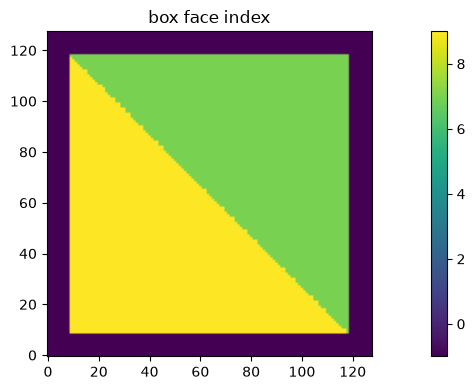

In [3]:
# Box smoke: face index → pixel map (no Beer–Lambert)
box = trimesh.primitives.Box()
face_values = np.arange(len(box.faces), dtype=float)

cam_box = pinhole_camera_framing_mesh(box, resolution=128)
rays_box = make_pinhole_rays(cam_box)
_valid, _depth, hit_faces_box = first_visible_hits(box, rays_box)

sampled_box = sample_face_values_to_image(hit_faces_box, face_values)
sampled_box = sampled_box.reshape(rays_box.sample_shape)

plot_face_sampled_row([sampled_box], ["box face index"])


In [4]:
# Bear mesh + auto-framed pinhole (M2A convention)
inspection = inspect_stl(ROOT / "cad" / "proto_bear.stl")
mesh = inspection["mesh"]
summary = inspection["summary"]

cam = pinhole_camera_framing_mesh(mesh)
rays = make_pinhole_rays(cam)
_valid, _depth, hit_faces = first_visible_hits(mesh, rays)

print(f"centroid={summary['centroid']}")
print(
    f"camera_position={cam.camera_position}  fov_deg={cam.fov_deg:.2f}  "
    f"resolution={cam.resolution}  valid_pixels={int(_valid.sum())}"
)


centroid=[-0.3784676994576298, -0.09824173923582938, 2.3279409780550253]
camera_position=(-0.3784676994576298, 72.4047154228263, 2.3279409780550253)  fov_deg=26.77  resolution=256  valid_pixels=20144


In [5]:
# Camera basis and ray-direction sanity
_eye, forward, right, up = pinhole_camera_basis(cam)
print("forward:", forward)
print("right:", right)
print("up:", up)
print("mean ray direction:", rays.directions.mean(axis=0))
print("center ray direction:", rays.directions[len(rays.directions) // 2])


forward: [ 0. -1.  0.]
right: [-1.  0.  0.]
up: [0. 0. 1.]
mean ray direction: [ 3.66765266e-18 -9.81703187e-01  4.70315044e-18]
center ray direction: [ 2.31472148e-01 -9.72841108e-01  9.07733915e-04]


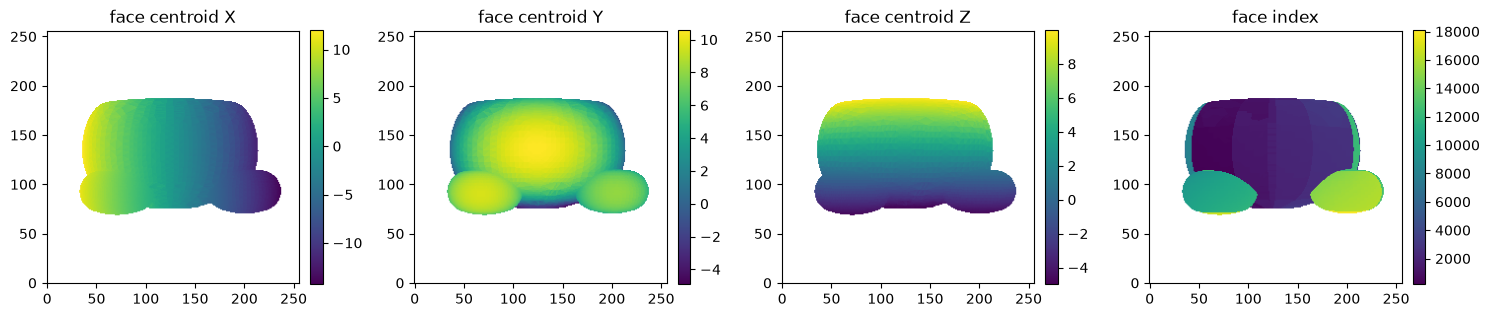

In [6]:
# Sample face centroid channels through hit_faces
channels = face_centroid_channels(mesh)
titles = ["face centroid X", "face centroid Y", "face centroid Z", "face index"]
images = sample_face_scalars_to_images(hit_faces, channels, rays.sample_shape)
plot_face_sampled_row(images, titles, figsize=(15, 4))
